In [1]:
import os
import tifffile
import stackview
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from skimage import exposure

In [2]:
time = 44
snr = "2"
typ = "mid"

In [3]:
root_dir = f"/nfs/scratch/ajain/virus_snr_{snr}_density_{typ}"

tif_files = [
    f for f in os.listdir(root_dir)
    if f.endswith(".tif") and not f.startswith(".")
]
tif_files.sort()

selected_file = tif_files[time]

volume_path = os.path.join(root_dir, selected_file)
volume = tifffile.imread(volume_path)
volume.shape

(10, 512, 512)

In [4]:
GT = pd.read_csv(f"Input SNR/snr_{snr}_{typ}_benchmark.csv")
GT = GT[["t","ID","x","y","z"]]
display(GT)
Dino = pd.read_csv(f"Input SNR/snr_{snr}_{typ}_centroids.csv", names = ["t","ID", "z", "y", "x"],skiprows=1)
Dino = Dino[["t","ID","x","y","z"]]
display(Dino)
Comp = pd.read_csv(f"Input SNR/DC_SNR_{snr}_{typ}.csv")

Dino_time = Dino[Dino["t"]==time]
GT_time = GT[GT["t"]==time]

Comp_col = Comp[Comp["Distance"]<3.5]
Comp_col_time = Comp_col[Comp_col["t"]==time]

Comp_col_time["Multi ID (GT)"] = Comp_col_time["Multi ID (GT)"].str.split(',')
Comp_col_time["Multi Distance (GT)"] = Comp_col_time["Multi Distance (GT)"].str.split(',')
Comp_col_time = Comp_col_time.explode(["Multi ID (GT)", "Multi Distance (GT)"])

Dino_ID_col = Comp_col_time["ID (Dino)"].unique()
GT_ID_col = Comp_col_time["Multi ID (GT)"].unique().astype(int)

Dino_clean = Dino_time[~Dino_time["ID"].isin(Dino_ID_col)].reset_index(drop=True)
GT_clean = GT_time[~GT_time["ID"].isin(GT_ID_col)].reset_index(drop=True)

,t,ID,x,y,z
0,0,105,179.182,175.364,0.091
1,1,105,178.909,174.727,0.273
2,2,105,178.727,174.000,0.455
3,3,105,179.000,173.545,0.091
4,4,105,177.909,173.727,0.091
...,...,...,...,...,...
46973,99,2883,248.636,438.182,3.636
46974,96,2884,507.727,346.455,5.091
46975,97,2884,506.909,346.909,5.091
46976,98,2884,506.000,347.818,5.000


,t,ID,x,y,z
0,0,0,254.766770,258.425450,4.011640
1,0,1,86.813140,1.585845,1.380683
2,0,2,98.458176,0.501558,0.817274
3,0,3,120.999756,0.000000,0.000000
4,0,4,166.485630,0.425288,1.772925
...,...,...,...,...,...
326719,99,3026,370.653600,510.509640,7.451407
326720,99,3027,415.203120,509.089300,7.878043
326721,99,3028,493.635960,510.690600,7.999994
326722,99,3029,501.926900,510.535030,6.929743


/tmp/ipykernel_2712609/450918692.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Comp_col_time["Multi ID (GT)"] = Comp_col_time["Multi ID (GT)"].str.split(',')
/tmp/ipykernel_2712609/450918692.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Comp_col_time["Multi Distance (GT)"] = Comp_col_time["Multi Distance (GT)"].str.split(',')


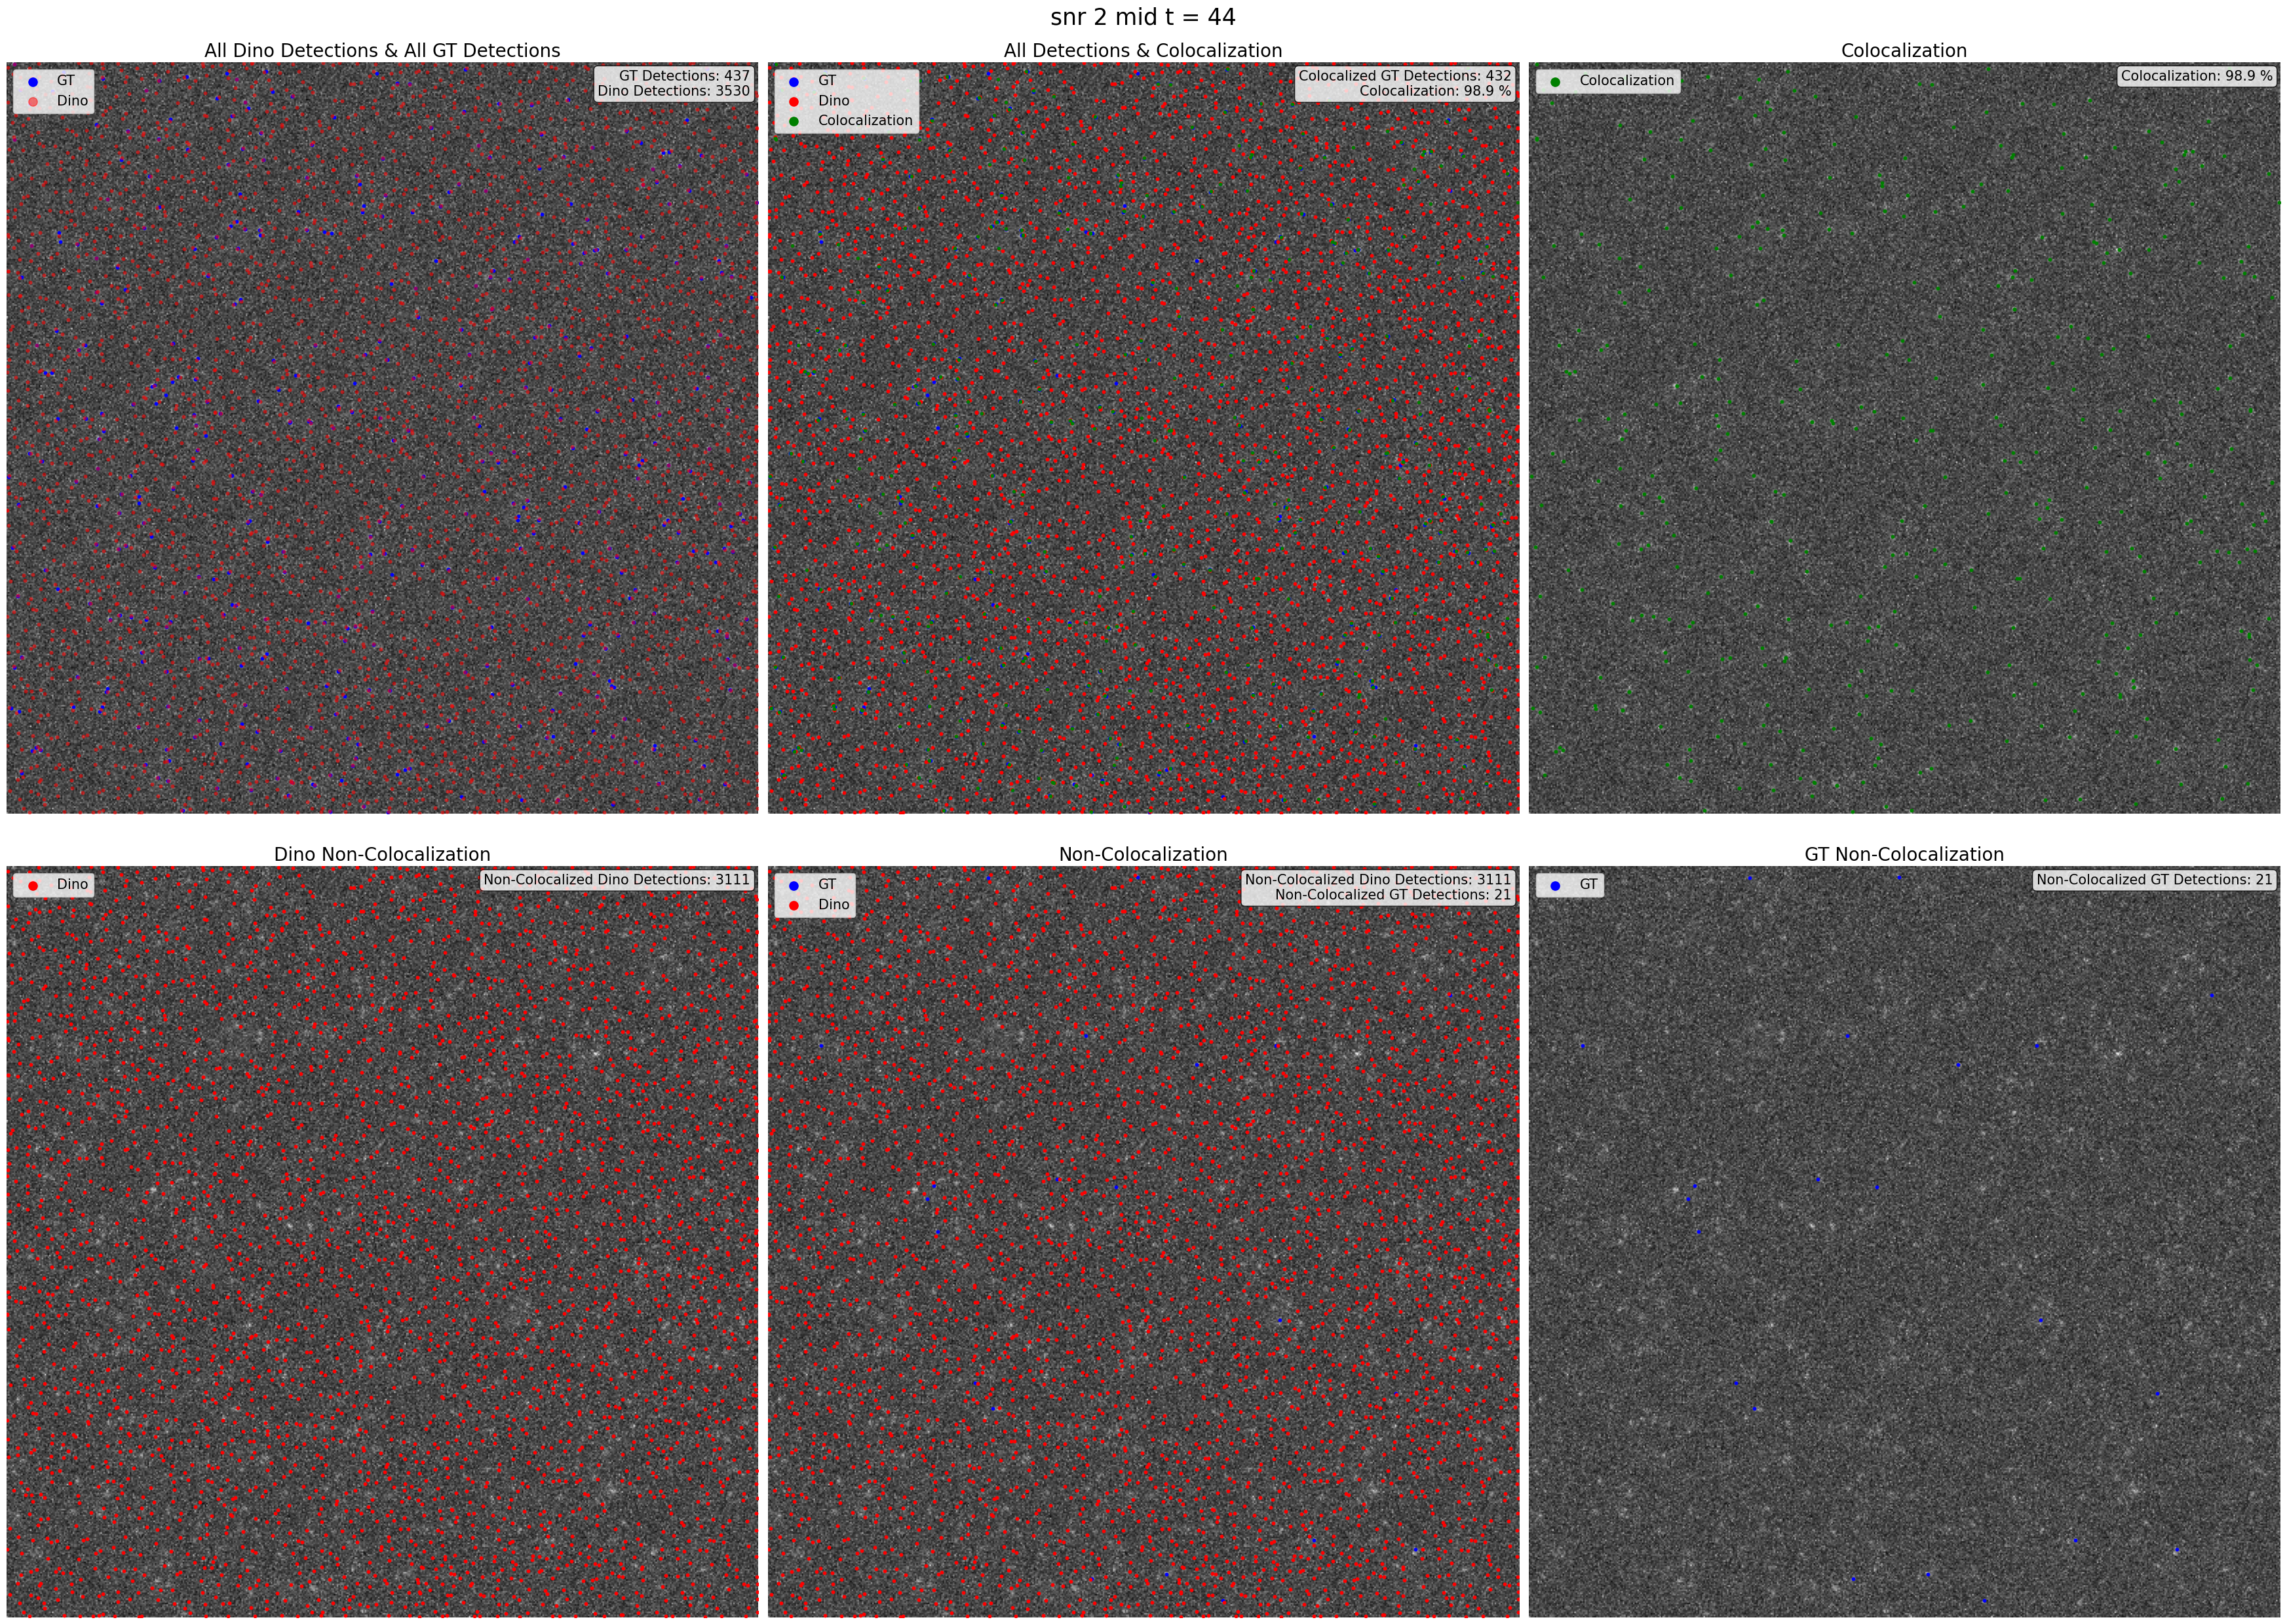

In [5]:
max_projection = np.max(volume, axis=0)

plt.figure(figsize=(35,26))

plt.subplot(2,3,1)
plt.imshow(max_projection, cmap="grey")
plt.scatter(GT_time.iloc[:,:]["x"],GT_time.iloc[:,:]["y"], s = 10,color = "blue", label ="GT")  # All GT detections for a time point
plt.scatter(Dino_time.iloc[:,:]["x"],Dino_time.iloc[:,:]["y"], s = 10, color = "red", label = "Dino",alpha=0.5)  # All Dino detections for a time point
plt.text(0.99, 0.99, f"GT Detections: {len(GT_time)}\nDino Detections: {len(Dino_time)}", fontsize =15,
         ha='right', va='top',
         transform=plt.gca().transAxes,
         bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3', alpha = 0.8))
plt.axis("off")
plt.legend(markerscale=3,fontsize = 15,loc=2)
plt.title("All Dino Detections & All GT Detections", fontsize=20)

plt.subplot(2,3,2)
plt.imshow(max_projection, cmap="grey")
plt.scatter(GT_time.iloc[:,:]["x"],GT_time.iloc[:,:]["y"], s = 10,color = "blue", label ="GT")  # All GT detections for a time point
plt.scatter(Dino_time.iloc[:,:]["x"],Dino_time.iloc[:,:]["y"], s = 10, color = "red", label = "Dino")  # All Dino detections for a time point
plt.scatter((Comp_col_time.iloc[:,:]["x (GT)"]+Comp_col_time.iloc[:,:]["x (Dino)"])/2,(Comp_col_time.iloc[:,:]["y (GT)"]+Comp_col_time.iloc[:,:]["y (Dino)"])/2, s = 10, color = "green", label = "Colocalization") # matched detections for a time point
plt.text(0.99, 0.99, f"Colocalized GT Detections: {len(Comp_col_time)}\nColocalization: {round(100*(len(Comp_col_time)/len(GT_time)),1)} %", fontsize =15,
         ha='right', va='top',
         transform=plt.gca().transAxes,
         bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3', alpha = 0.8))
plt.axis("off")
plt.legend(markerscale=3,fontsize =15,loc=2)
plt.title("All Detections & Colocalization", fontsize=20)

plt.subplot(2,3,3)
plt.imshow(max_projection, cmap="grey")
plt.scatter((Comp_col_time.iloc[:,:]["x (GT)"]+Comp_col_time.iloc[:,:]["x (Dino)"])/2,(Comp_col_time.iloc[:,:]["y (GT)"]+Comp_col_time.iloc[:,:]["y (Dino)"])/2, s = 10, color = "green", label = "Colocalization") # matched detections for a time point
plt.axis("off")
plt.text(0.99, 0.99, f"Colocalization: {round(100*(len(Comp_col_time)/len(GT_time)),1)} %", fontsize =15,
         ha='right', va='top',
         transform=plt.gca().transAxes,
         bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3', alpha = 0.8))
plt.legend(markerscale=3,fontsize =15,loc=2)
plt.title("Colocalization", fontsize=20)


plt.subplot(2,3,4)
plt.imshow(max_projection, cmap="grey")
plt.scatter(Dino_clean.iloc[:,:]["x"],Dino_clean.iloc[:,:]["y"], s = 10, color = "red", label = "Dino")  # Dino detections with matches removed for at time point
plt.text(0.99, 0.99, f"Non-Colocalized Dino Detections: {len(Dino_clean)}", fontsize =15,
         ha='right', va='top',
         transform=plt.gca().transAxes,
         bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3', alpha = 0.8))
plt.axis("off")
plt.legend(markerscale=3,fontsize =15,loc=2)
plt.title("Dino Non-Colocalization", fontsize=20)

plt.subplot(2,3,5)
plt.imshow(max_projection, cmap="grey")
plt.scatter(GT_clean.iloc[:,:]["x"],GT_clean.iloc[:,:]["y"], s = 10,color = "blue", label = "GT")  # GT detections with matches removed for at time point
plt.scatter(Dino_clean.iloc[:,:]["x"],Dino_clean.iloc[:,:]["y"], s = 10, color = "red", label = "Dino")  # Dino detections with matches removed for at time point
plt.axis("off")
plt.text(0.99, 0.99, f"Non-Colocalized Dino Detections: {len(Dino_clean)}\nNon-Colocalized GT Detections: {len(GT_clean)}", fontsize =15,
         ha='right', va='top',
         transform=plt.gca().transAxes,
         bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3', alpha = 0.8))
plt.legend(markerscale=3,fontsize =15,loc=2)
plt.title("Non-Colocalization", fontsize=20)

plt.subplot(2,3,6)
plt.imshow(max_projection, cmap="grey")
plt.scatter(GT_clean.iloc[:,:]["x"],GT_clean.iloc[:,:]["y"], s = 10,color = "blue", label = "GT")  # GT detections with matches removed for at time point
plt.axis("off")
plt.text(0.99, 0.99, f"Non-Colocalized GT Detections: {len(GT_clean)}", fontsize =15,
         ha='right', va='top',
         transform=plt.gca().transAxes,
         bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.3', alpha = 0.8))
plt.legend(markerscale=3,fontsize =15,loc=2)
plt.title("GT Non-Colocalization", fontsize=20)

plt.suptitle(f"snr {snr} {typ} t = {time}", fontsize = 25)
plt.tight_layout()
plt.savefig(f"snrplots/snr{snr}_{typ}_t{time}.png")
plt.show()